In [ ]:
import yfinance as yf
import pandas  as pd
import matplotlib.pyplot as plt
import math as m 
import numpy as np

In [ ]:
spy=yf.Ticker("SPY")
spy_data=spy.history(period="5y")
df=pd.DataFrame(spy_data)
df.drop(['Dividends','Capital Gains',"Stock Splits"],axis=1,inplace=True)
df.head()

In [ ]:
df.columns

In [ ]:
plt.plot(df.index,df["Close"])
plt.xlabel("Day")
plt.ylabel("price")
plt.show()
plt.plot(df.index,df["Volume"])
plt.xlabel("Day")
plt.ylabel("volume")
plt.show()

# Return Features

In [ ]:
df['return']=np.log(df['Close']/df['Close'].shift(1))
df["5_d_mean_return"]=df["return"].rolling(window=5).mean()
df["21_d_mean_return"]=df["return"].rolling(window=21).mean()
df["63_d_mean_return"]=df["return"].rolling(window=63).mean()
df["21_d_cum_return"]=np.log(df["Close"]/df['Close'].shift(21))
df["63_d_cum_return"]=np.log(df["Close"]/df['Close'].shift(63))

In [ ]:
df.head()

# Momentum indicators (RSI(14) AND MACD)

In [ ]:
df['delta']=df['Close'].diff()
df['gain']=df['delta'].apply(lambda x:x if x>0 else 0)
df['loss']=df['delta'].apply(lambda x:-x if x<0 else 0)
df['avg_gain']=df['gain'].rolling(14).mean()
df['avg_loss']=df['loss'].rolling(14).mean()
df['rsi14']=100-(100/(1+(df['avg_gain']/df['avg_loss'])))
df.drop(['delta','gain',"loss",'avg_gain','avg_loss'],axis=1,inplace=True)

In [ ]:
df['ema_12']=df['Close'].ewm(span=12,adjust=False).mean()
df['ema_26']=df['Close'].ewm(span=26,adjust=False).mean()
df['macd_line']=df['ema_12']-df['ema_26']
df['signal_line']=df['macd_line'].ewm(span=9,adjust=False).mean()
df['macd_histogram']=df['macd_line']-df['signal_line']

df.drop(['ema_12','ema_26',"macd_line",'signal_line'],axis=1,inplace=True)

In [ ]:
df.tail()

# Volatility Indicators

In [ ]:
df["10_d_volatility"]=df["return"].rolling(window=10).std()
df["21_d_volatility"]=df["return"].rolling(window=21).std()
df["63_d_volatility"]=df["return"].rolling(window=63).std()

df["21_d_std_volatility"]=df["21_d_volatility"].rolling(window=21).std()

In [ ]:
df["intra_mov"]=df["High"]-df["Low"]
df["gap_up"]=abs(df["High"]-df["Close"].shift(1))
df["gap_down"]=abs(df["Low"]-df["Close"].shift(1))

df["atr_raw"]=df.apply(lambda x : max(x["intra_mov"],x["gap_up"],x["gap_down"]),axis=1)

df["atr_14_d"]=df["atr_raw"].rolling(window=14).mean()
df["atr_14_d"]=df["atr_14_d"]/df['Close']

df.drop(["intra_mov","gap_up","gap_down","atr_raw"],axis=1,inplace=True)

In [ ]:
df["max_close_63_d"]=df["Close"].rolling(window=63).max()
df["dist_from_high"]=df["Close"]-df["max_close_63_d"]
df["dist_from_high"]=df["dist_from_high"]/df["max_close_63_d"]

df.drop(["max_close_63_d"],axis=1,inplace=True)

In [ ]:
def rolling_max_drawdown(prices):
    running_peak = prices.cummax()
    drawdowns = (prices - running_peak) / running_peak
    return drawdowns.min()

df["rolling_max_drawdown_63"] = (
    df["Close"]
    .rolling(window=63)
    .apply(rolling_max_drawdown, raw=False)
)


In [ ]:
df.tail()

# Trend & structure

In [ ]:
df["SMA_20"]=df["Close"].rolling(window=20).mean()
df["SMA_50"]=df["Close"].rolling(window=50).mean()
df["SMA_200"]=df["Close"].rolling(window=200).mean()

### Trend Structure Features

In [ ]:
df["price_per_sma_200"]=df["Close"]/df["SMA_200"]
df["(SMA20 − SMA50)per_Price"]=(df["SMA_20"]-df["SMA_50"])/df["Close"]
df["(SMA50 − SMA200)per_Price"]=(df["SMA_50"]-df["SMA_200"])/df["Close"]

df["trend_strength_sma50"] = (df["SMA_50"].diff().abs()) / df["Close"]

In [ ]:
df.shape

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

In [ ]:
df.to_csv("feature_engineered_dataset.csv")

In [ ]:
df_1=pd.read_csv("feature_engineered_dataset.csv")

In [ ]:
df_1.columns

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
hdbscan_main=df_1[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]].copy()
hdbscan_main[["21_d_mean_return",
              "21_d_volatility",
              '21_d_std_volatility',
              "price_per_sma_200",
              "rolling_max_drawdown_63"]]=scaler.fit_transform(hdbscan_main[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]])

In [ ]:
hdbscan_main.head()

In [ ]:
hdbscan_main.describe()

In [ ]:
hdbscan_main.columns

In [ ]:
hdbscan_main.to_csv("HDBSCAN_df.csv")

## **Training HDBSCAN to find probable Regimes**

In [ ]:
!pip install hdbscan>=0.8.38
import sklearn
import hdbscan
print(sklearn.__version__)
import importlib.metadata
importlib.metadata.version("hdbscan")

## Iterations for regime discovery 

### Combination of features used for the first iteration of regime discovery
#### ['21_d_mean_return', '21_d_volatility', '21_d_std_volatility','price_per_sma_200', 'rolling_max_drawdown_63']

In [ ]:

x=hdbscan_main[['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63']]

clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=15)
labels = clusterer.fit_predict(x)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=12)
labels = clusterer.fit_predict(x)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=17)
labels = clusterer.fit_predict(x)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=18)
labels = clusterer.fit_predict(x)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=70, min_samples=15)
labels = clusterer.fit_predict(x)

np.unique(labels, return_counts=True)

### Interpretation of first  iteration -
feature space contains:

-volatility  
-drawdown  
-trend  
-instability  

TOTAL SAMPLE DATAPOINTS -1056 (approx-4yrs of data)   
The model recognizes **2** regimes in the given timeline

-at min_samples=12 - Noise(%)\~**17%**    Large Regime\~**811 days**    Small Regime\~**65 days**   
-at min_samples=15 - Noise(%)\~**52%**    Large Regime\~**448 days**    Small Regime\~**60 days**   
-at min_samples=17 - Noise(%)\~**55%**    Large Regime\~**435 days**    Small Regime\~**41 days**  
-at min_samples=18 - Noise(%)\~**100%**   Large Regime\~**0 days**      Small Regime\~**0 days**


#### Key interpretation - 
The model recognizes **one very strong long regime** , **one weaker stress regime** and a **huge fuzzy transition zone** in between the two which is an expected behavior of financial markets

## Combination of features used for the second iteration of regime discovery
### ['21_d_mean_return', '21_d_volatility', '21_d_std_volatility','63_d_volatility','price_per_sma_200', 'rolling_max_drawdown_63']
#### Added 63_d_volatility 

In [ ]:
hdbscan_2=df_1[["21_d_mean_return","21_d_volatility",'21_d_std_volatility','63_d_volatility',"price_per_sma_200","rolling_max_drawdown_63"]].copy()
hdbscan_2[["21_d_mean_return",
              "21_d_volatility",
              '21_d_std_volatility','63_d_volatility',
              "price_per_sma_200",
              "rolling_max_drawdown_63"]]=scaler.fit_transform(hdbscan_2[["21_d_mean_return","21_d_volatility",'21_d_std_volatility','63_d_volatility',"price_per_sma_200","rolling_max_drawdown_63"]])

In [ ]:
X=hdbscan_2[["21_d_mean_return","21_d_volatility",'21_d_std_volatility','63_d_volatility',"price_per_sma_200","rolling_max_drawdown_63"]]
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=15)
labels = clusterer.fit_predict(X)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=17)
labels = clusterer.fit_predict(X)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=18)
labels = clusterer.fit_predict(X)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=19)
labels = clusterer.fit_predict(X)

np.unique(labels, return_counts=True)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=23)
labels = clusterer.fit_predict(X)

np.unique(labels, return_counts=True)

## Interpretation of second iteration -  
feature space contains:

-volatility (long term and short term)  
-drawdown  
-trend  
-instability  

TOTAL SAMPLE DATAPOINTS -1056 (approx-4yrs of data)
The model recognizes **2** regimes in the given timeline

-at min_samples=15 - Noise(%)\~**17%** Large Regime\~**801** days Small Regime\~**65** days  
-at min_samples=17 - Noise(%)\~**21%** Large Regime\~**782** days Small Regime\~**48** days  
-at min_samples=18 - Noise(%)\~**84%** Large Regime\~**108** days Small Regime\~**56** days  
-at min_samples=19 - Noise(%)\~**85%** Large Regime\~**108** days Small Regime\~**46** days    
-at min_samples=23 - Noise(%)\~**100%** Large Regime\~**0** days Small Regime\~**0** days

#### Key interpretation -  
-The model with a seperate set of features and dimensionality still supports the findings of the previous models, **2** regimes and a **fuzzy transition zone**    
-collapse point (everything=noise) shifts from min_samples ≈ 18 to ≈ 23 caused as the **long-term volatility added a stabilizing axis**

#  **Phase 2: Probabilistic Regime Modeling.**

## Fitting Gaussian Mixture Model (GMM) to turn hard/noisy regimes found by HDBSCAN into soft probabilistic regimes.

In [1]:
import yfinance as yf
import pandas  as pd
import matplotlib.pyplot as plt
import math as m 
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [2]:
df_1=pd.read_csv(r"C:\Users\Rehan Imtiyaj Mulla\OneDrive\Documents\PROJECT FILES\RegimeX\dataset\feature_engineered_dataset.csv")
split_idx = int(0.8 * len(df_1))
df_train = df_1.iloc[:split_idx].copy()
df_test  = df_1.iloc[split_idx:].copy()

gmm_train=df_train[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]].copy()
gmm_train[["21_d_mean_return",
              "21_d_volatility",
              '21_d_std_volatility',
              "price_per_sma_200",
              "rolling_max_drawdown_63"]]=scaler.fit_transform(gmm_train[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]])

gmm_test=df_test[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]].copy()
gmm_test[["21_d_mean_return",
              "21_d_volatility",
              '21_d_std_volatility',
              "price_per_sma_200",
              "rolling_max_drawdown_63"]]=scaler.transform(gmm_test[["21_d_mean_return","21_d_volatility",'21_d_std_volatility',"price_per_sma_200","rolling_max_drawdown_63"]])

gmm_train.columns

Index(['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63'],
      dtype='object')

In [3]:
print(len(df_train))
print(len(df_test))

844
212


In [4]:
x_train=gmm_train[['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63']]
gmm= GaussianMixture(n_components=2)
gmm.fit(x_train)

C:\Users\Rehan Imtiyaj Mulla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Rehan Imtiyaj Mulla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Rehan Imtiyaj Mulla\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Rehan Imtiyaj Mulla\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Rehan Imtiyaj Mulla\anaconda3\Lib\subprocess.py",

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [5]:
component_means=gmm.means_
print("Means for each component (shape: n_components x n_features):\n", component_means)

Means for each component (shape: n_components x n_features):
 [[ 0.24435222 -0.61454942 -0.45383795  0.53843165  0.53418352]
 [-0.37702571  0.94822518  0.70025382 -0.83077852 -0.82422382]]


In [6]:
gmm_train.columns

Index(['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63'],
      dtype='object')

# Interpretation of cluster centroid plotted by GMM

## Cluster 0 (as per mean vector)
21_d_mean_return  =  **0.17591888**  (Above average returns)  
21_d_volatility  = **-0.47364605**  (Below average volatility)  
21_d_std_volatility  = **-0.29460852**  (Stable  volatility)  
price_per_sma_200  = **0.48645257**  (Price above long-term trend)  
rolling_max_drawdown_63  =**0.49830196**  (shallow drawdown)  

#### **INTERPRETATION**- **Calm / Bull regime**    
Trending markets with low risk and shallow pullbacks

## Cluster 1 (as per mean vector)
21_d_mean_return  =  **-0.4213043**  (below average returns)  
21_d_volatility  = **1.13432462**  (very high volatility)  
21_d_std_volatility  = **0.70555154**  (unstable , spiking volatility)  
price_per_sma_200  = **-1.16499467**  (price far below trend)  
rolling_max_drawdown_63  = **-1.19337252**  (deep drawdown)  

#### **INTERPRETATION** - **Stress / Bear regime**
Risk-off markets with turbulence, drawdowns, and structural weakness 

In [7]:
x_test=gmm_test[['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63']]
print(gmm_test.columns)
len(gmm_test)

Index(['21_d_mean_return', '21_d_volatility', '21_d_std_volatility',
       'price_per_sma_200', 'rolling_max_drawdown_63'],
      dtype='object')


212

In [8]:
prob_matrix_df_train=gmm.predict_proba(x_train)
prob_df_train=pd.DataFrame(prob_matrix_df_train)
prob_df_train.columns = ['p(calm)', 'p(stress)']
gmm_train=gmm_train.join(prob_df_train)


prob_matrix_df_test=gmm.predict_proba(x_test)
prob_df_test=pd.DataFrame(prob_matrix_df_test)
prob_df_test.index=gmm_test.index
prob_df_test.columns = ['p(calm)', 'p(stress)']
gmm_test=gmm_test.join(prob_df_test)


In [9]:
gmm_train.head()

,21_d_mean_return,21_d_volatility,21_d_std_volatility,price_per_sma_200,rolling_max_drawdown_63,p(calm),p(stress)
0,0.586730,-0.221464,-0.055576,0.646188,0.548159,0.966384,0.033616
1,0.294397,-0.296119,-0.202972,0.617053,0.548159,0.982185,0.017815
2,0.376941,-0.284001,-0.383676,0.682331,0.548159,0.984453,0.015547
3,0.460860,-0.296070,-0.632966,0.681261,0.548159,0.988178,0.011822
4,0.815700,-0.637861,-0.573696,0.601618,0.548159,0.992132,0.007868


In [10]:
gmm_test.head()

,21_d_mean_return,21_d_volatility,21_d_std_volatility,price_per_sma_200,rolling_max_drawdown_63,p(calm),p(stress)
844,-0.755495,-0.178625,-0.393490,-0.261666,0.373879,0.962813,0.037187
845,-1.303802,-0.056838,-0.258327,-0.514028,0.220770,0.842751,0.157249
846,-1.269409,-0.043033,-0.110293,-0.443821,0.220770,0.789520,0.210480
847,-1.948564,0.270145,0.229478,-0.812980,-0.226743,0.066258,0.933742
848,-1.929663,0.265393,0.497410,-0.927267,-0.398670,0.025045,0.974955


In [11]:
import matplotlib.pyplot as plt

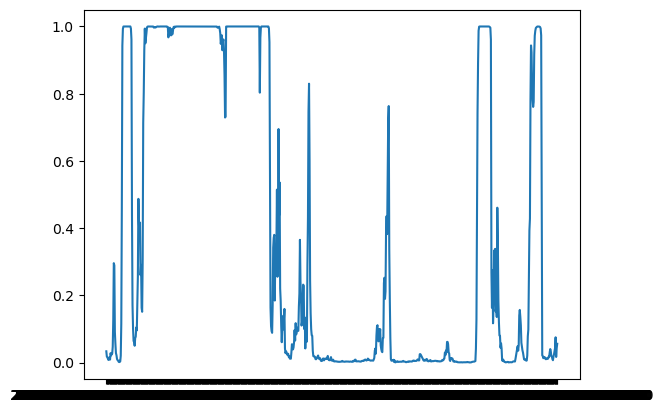

In [12]:
plt.plot(df_train["Date"],gmm_train["p(stress)"])
plt.show()

(array([439.,  44.,  21.,  16.,  12.,   4.,   2.,  11.,   6., 289.]),
 array([3.65438166e-04, 1.00328894e-01, 2.00292351e-01, 3.00255807e-01,
        4.00219263e-01, 5.00182719e-01, 6.00146175e-01, 7.00109631e-01,
        8.00073088e-01, 9.00036544e-01, 1.00000000e+00]),
 <BarContainer object of 10 artists>)

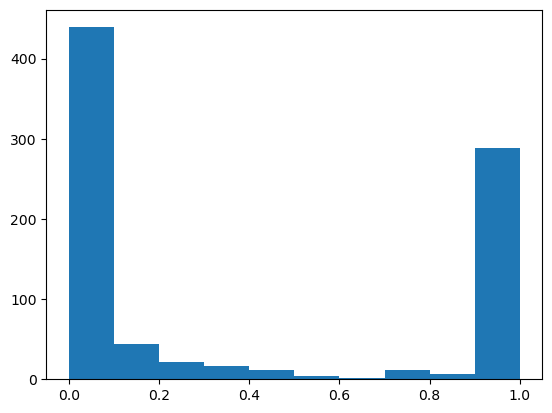

In [13]:
plt.hist(gmm_train["p(stress)"])

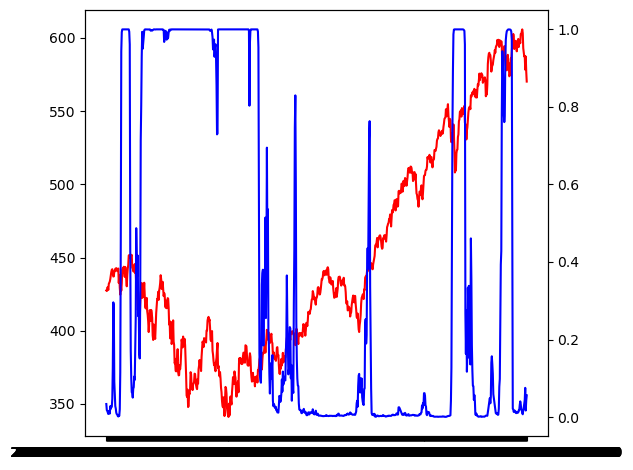

In [14]:
fig, ax1 = plt.subplots() 
ax2 = ax1.twinx()       

ax1.plot(df_train["Date"],df_train["Close"],color="red")
ax2.plot(df_train["Date"],gmm_train["p(stress)"],color="blue")

fig.tight_layout() 
plt.show()

In [15]:
import joblib

In [16]:
joblib.dump(gmm, 'gmm_model_latest.pkl')

['gmm_model_latest.pkl']

In [17]:
df_train.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'return',
       '5_d_mean_return', '21_d_mean_return', '63_d_mean_return',
       '21_d_cum_return', '63_d_cum_return', 'rsi14', 'macd_histogram',
       '10_d_volatility', '21_d_volatility', '63_d_volatility',
       '21_d_std_volatility', 'atr_14_d', 'dist_from_high',
       'rolling_max_drawdown_63', 'SMA_20', 'SMA_50', 'SMA_200',
       'price_per_sma_200', '(SMA20 − SMA50)per_Price',
       '(SMA50 − SMA200)per_Price', 'trend_strength_sma50'],
      dtype='object')

In [18]:
df_train=df_train.join(prob_df_train)

In [19]:
df_test=df_test.join(prob_df_test)

In [20]:
df_train['target']=(df_train['Close'].shift(-1)>df_train['Close']).astype(int)
df_train.dropna(inplace=True)

df_test['target']=(df_test['Close'].shift(-1)>df_test['Close']).astype(int)
df_test.dropna(inplace=True)

In [24]:
df_train.tail()

,Date,Open,High,Low,Close,Volume,return,5_d_mean_return,21_d_mean_return,63_d_mean_return,...,SMA_20,SMA_50,SMA_200,price_per_sma_200,(SMA20 − SMA50)per_Price,(SMA50 − SMA200)per_Price,trend_strength_sma50,p(calm),p(stress),target
839,2025-02-26 00:00:00-05:00,589.013041,592.620700,584.990274,587.639160,43321600,0.000504,-0.006093,-0.000385,0.000077,...,596.653894,591.418698,560.781790,1.047893,0.008909,0.052136,0.000366,0.956234,0.043766,0
840,2025-02-27 00:00:00-05:00,589.922426,591.078890,577.864078,578.259399,74196700,-0.016091,-0.008477,-0.001559,-0.000228,...,595.825623,591.077644,561.127096,1.030532,0.008211,0.051794,0.000590,0.924731,0.075269,1
841,2025-02-28 00:00:00-05:00,578.763503,587.817158,575.679721,587.283447,88744100,0.015485,-0.001929,-0.000608,-0.000036,...,595.288925,590.919437,561.514242,1.045892,0.007440,0.050070,0.000269,0.983172,0.016828,0
842,2025-03-03 00:00:00-05:00,589.260195,590.406764,573.169186,576.994263,74249200,-0.017675,-0.004552,-0.001704,-0.000399,...,594.396899,590.504617,561.849600,1.026955,0.006746,0.049663,0.000719,0.957262,0.042738,0
843,2025-03-04 00:00:00-05:00,572.981447,578.595513,565.608012,570.164490,109648200,-0.011907,-0.005937,-0.002017,-0.000540,...,593.363535,590.002455,562.139111,1.014276,0.005895,0.048869,0.000881,0.944009,0.055991,0


In [22]:
df_test.head()

,Date,Open,High,Low,Close,Volume,return,5_d_mean_return,21_d_mean_return,63_d_mean_return,...,SMA_20,SMA_50,SMA_200,price_per_sma_200,(SMA20 − SMA50)per_Price,(SMA50 − SMA200)per_Price,trend_strength_sma50,p(calm),p(stress),target
844,2025-03-05 00:00:00-05:00,569.996421,578.091363,566.428337,576.292480,71230500,0.010690,-0.003900,-0.001186,-0.000469,...,592.438397,589.977677,562.427546,1.024652,0.004270,0.047806,0.000043,0.962813,0.037187,0
845,2025-03-06 00:00:00-05:00,568.800430,573.435996,563.502657,566.062622,80094900,-0.017911,-0.004264,-0.002358,-0.000781,...,590.881183,589.751849,562.670167,1.006029,0.001995,0.047842,0.000399,0.842751,0.157249,1
846,2025-03-07 00:00:00-05:00,564.273659,570.688321,559.064808,569.235352,81158800,0.005589,-0.006243,-0.002284,-0.000700,...,589.378824,589.450784,562.924931,1.011210,-0.000126,0.046599,0.000529,0.789520,0.210480,0
847,2025-03-10 00:00:00-04:00,561.002132,562.929451,549.141414,554.073486,99326600,-0.026997,-0.008107,-0.003735,-0.001227,...,587.392648,588.776503,563.100900,0.983968,-0.002498,0.046340,0.001217,0.066258,0.933742,0
848,2025-03-11 00:00:00-04:00,552.907117,557.473488,545.612771,549.467468,88102100,-0.008348,-0.007395,-0.003695,-0.001333,...,584.974542,587.879436,563.247476,0.975535,-0.005287,0.044829,0.001633,0.025045,0.974955,1


In [23]:
df_train.to_csv(r"C:\Users\Rehan Imtiyaj Mulla\OneDrive\Documents\PROJECT FILES\RegimeX\dataset\df_train.csv")
df_test.to_csv(r"C:\Users\Rehan Imtiyaj Mulla\OneDrive\Documents\PROJECT FILES\RegimeX\dataset\df_test.csv")